In [1]:
#%load_ext autoreload
#%autoreload 2

# Task 3: Eigenfaces & Fischerfaces (4 pts)

### <div align="right"> &copy; Markiian Novosad & Rostyslav Hryniv, 2023 </div>

## Completed by:   
*   Ivan Havlytskyi
*   Oleksandr Kharytonov


In this task your main goal is to discuss dimensionality reduction techniques, such as **PCA** and **LDA** and their performance on classification tasks.

A good source to read more on these methods is the book

*   Kevin P. Murphy. [Probabilistic Machine Learning: An Introduction](https://probml.github.io/pml-book/book1.html), MIT, 2022. Section 9.2.6 (FLDA), 20.1 (PCA and Eigenfaces)


## 1. Lib and Data prep (0.5 pts)
#### Let's start with importing all neccesary libraries and preparing our data

In [2]:
from PIL import Image
from sklearn.datasets import fetch_lfw_people
import numpy as np
from sklearn.svm import SVC
import sklearn
from matplotlib import pyplot as plt
import scipy
from sklearn.model_selection import train_test_split

Seed libs, so we get the same results every time:

In [3]:
np.random.seed(1)

Fetch data and split them into training and test sets:

In [4]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.3)
n, h, w = lfw_people.images.shape
labels = lfw_people.target

print("Available classes and their counts:")
for i, name in enumerate(lfw_people.target_names):
    count = np.sum(labels == i)
    print(f"  Class {i}: {name} - {count} samples")



Available classes and their counts:
  Class 0: Colin Powell - 236 samples
  Class 1: Donald Rumsfeld - 121 samples
  Class 2: George W Bush - 530 samples
  Class 3: Gerhard Schroeder - 109 samples
  Class 4: Tony Blair - 144 samples


**We choose two classes with approximately equal number of samples**

In [5]:
# classes 1 and 3 (Colin Powell and Gerhard Schroeder) have similar counts
class1, class2 = 1, 3

x = lfw_people.data[(labels == class1) | (labels == class2)]
y = labels[(labels == class1) | (labels == class2)]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Image dimensions: {h} x {w}")

Training set shape: (161, 1036)
Test set shape: (69, 1036)
Image dimensions: 37 x 28


Visualise our data:

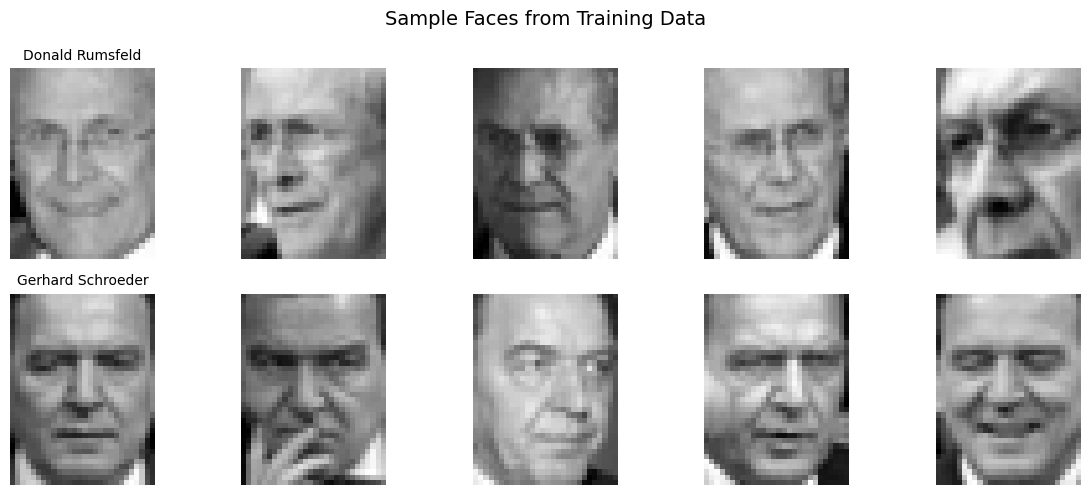

In [6]:
# ========= YOUR CODE STARTS HERE ========= #

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Faces from Training Data', fontsize=14)

# Show 5 samples from each class
for row, cls in enumerate([class1, class2]):
    class_samples = x_train[y_train == cls][:5]
    class_name = lfw_people.target_names[cls]
    for col, sample in enumerate(class_samples):
        axes[row, col].imshow(sample.reshape(h, w), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=10)

plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ========== #

## 2. PCA (2 pt)

### **2.1 Implementation (1 pt)**
Let's start implementing the **PCA** algorithm

In [7]:
class MYPCA:
    def __init__(self) -> None:
        self._data_mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self._k_components = None
        self.components = None

    def _get_num_components(self, lambdas, threshold) -> int:
        """
        Calculate minimal number of principal components so that variance explainability >= threshold.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        # sort eigenvalues in descending order
        sorted_lambdas = np.sort(lambdas)[::-1]
        total_variance = np.sum(sorted_lambdas)

        # cumulative sum of explained variance
        cumulative_variance = np.cumsum(sorted_lambdas) / total_variance

        # find minimal k where cumulative variance >= threshold
        k = np.argmax(cumulative_variance >= threshold) + 1
        return k
        # ========== YOUR CODE ENDS HERE ========== #

    def center_data(self, data):
        """
        Center our data by subtracting the mean
        """
        # ========= YOUR CODE STARTS HERE ========= #
        self._data_mean = np.mean(data, axis=0)
        return data - self._data_mean
        # ========== YOUR CODE ENDS HERE ========== #

    def compute_eigen(self, cov_mat):
        """
        Using built-in numpy functionality, compute eigenvectors and eigenvalues of covariance matrix;
        """
        # ========= YOUR CODE STARTS HERE ========= #
        # use eigh for symmetric matrices (covariance matrix is symmetric)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

        # descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        # ========== YOUR CODE ENDS HERE ========== #

        return eigenvalues, eigenvectors

    def fit(self, data, exp_threshold=0.8):
        """
        1. Center the data;
        2. Compute covariance matrix
        3. Compute optimal k (number of components)
        4. Compute top-k eigenvalues from covariance matrix
        5. Compute components by projecting data with eigenvectors
        """
        # ========= YOUR CODE STARTS HERE ========= #
        # 1. Center the data
        data_norm = self.center_data(data)

        # 2. Compute covariance matrix
        # for high-dimensional data (D >> N), use the trick: compute X^T X instead of X X^T
        # this gives an N x N matrix instead of D x D
        N = data_norm.shape[0]
        cov_mat = (data_norm.T @ data_norm) / (N - 1)

        # 3 & 4. Compute eigenvalues and eigenvectors
        self.eigenvalues, self.eigenvectors = self.compute_eigen(cov_mat)

        # get optimal number of components
        self._k_components = self._get_num_components(self.eigenvalues, exp_threshold)

        # 5. Select top-k eigenvectors (these are the principal components)
        top_k_vectors = self.eigenvectors[:, :self._k_components]

        # store components (the eigenvectors themselves are the components)
        self.components = top_k_vectors
        # ========== YOUR CODE ENDS HERE ========== #

    def plot_components(self, im_shape=None):
        """
        For better understanding, visualise the *self.components* variable.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        if im_shape is None:
            im_shape = (h, w)

        n_components_to_show = min(10, self._k_components)
        fig, axes = plt.subplots(2, 5, figsize=(12, 5))
        fig.suptitle('First 10 Eigenfaces (Principal Components)', fontsize=14)

        for i, ax in enumerate(axes.flat):
            if i < n_components_to_show:
                eigenface = self.components[:, i].reshape(im_shape)
                ax.imshow(eigenface, cmap='gray')
                ax.set_title(f'PC {i+1}')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        # ========== YOUR CODE ENDS HERE ========== #

    def plot_explainability(self):
        """
        Plot dependence of variance explainability on number of components.
        """
        # ========= YOUR CODE STARTS HERE ========= #
        total_variance = np.sum(self.eigenvalues)
        cumulative_variance = np.cumsum(self.eigenvalues) / total_variance

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # cumulative explained variance
        ax1.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
        ax1.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
        ax1.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
        ax1.axvline(x=self._k_components, color='orange', linestyle=':',
                    label=f'k={self._k_components} components')
        ax1.set_xlabel('Number of Components')
        ax1.set_ylabel('Cumulative Explained Variance Ratio')
        ax1.set_title('Cumulative Variance Explainability')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim([0, min(100, len(cumulative_variance))])

        # individual eigenvalue magnitudes (scree plot)
        individual_variance = self.eigenvalues / total_variance
        ax2.bar(range(1, min(51, len(individual_variance) + 1)),
                individual_variance[:50], alpha=0.7)
        ax2.set_xlabel('Principal Component')
        ax2.set_ylabel('Explained Variance Ratio')
        ax2.set_title('Scree Plot (First 50 Components)')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Number of components for 80% variance: {self._k_components}")
        print(f"Explained variance with {self._k_components} components: {cumulative_variance[self._k_components-1]:.4f}")
        # ========== YOUR CODE ENDS HERE ========== #

    def transform(self, data):
        """
        1. Center the data;
        2. Projection onto the components
        """
        # ========= YOUR CODE STARTS HERE ========= #
        data_norm = data - self._data_mean
        return data_norm @ self.components
        # ========== YOUR CODE ENDS HERE ========== #

### **2.2 PCA Classifier (0.5 pt)**
Having implemented the **MYPCA** class, let's plot how our components look like and our explainability plot

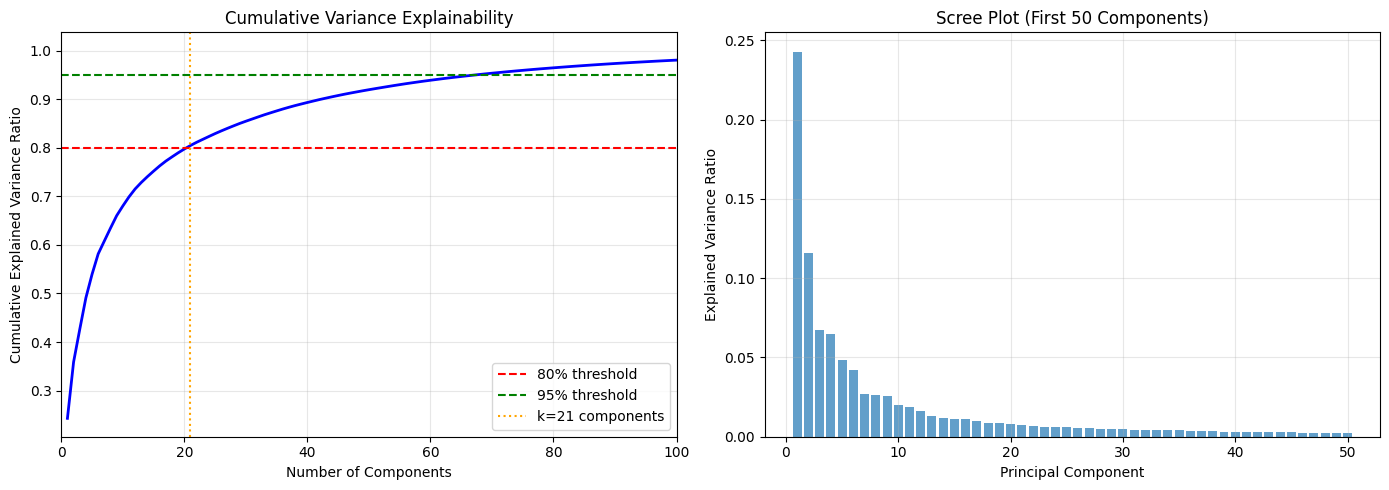

Number of components for 80% variance: 21
Explained variance with 21 components: 0.8048


In [8]:
pca = MYPCA()
pca.fit(x_train, exp_threshold=0.8)
pca.plot_explainability()

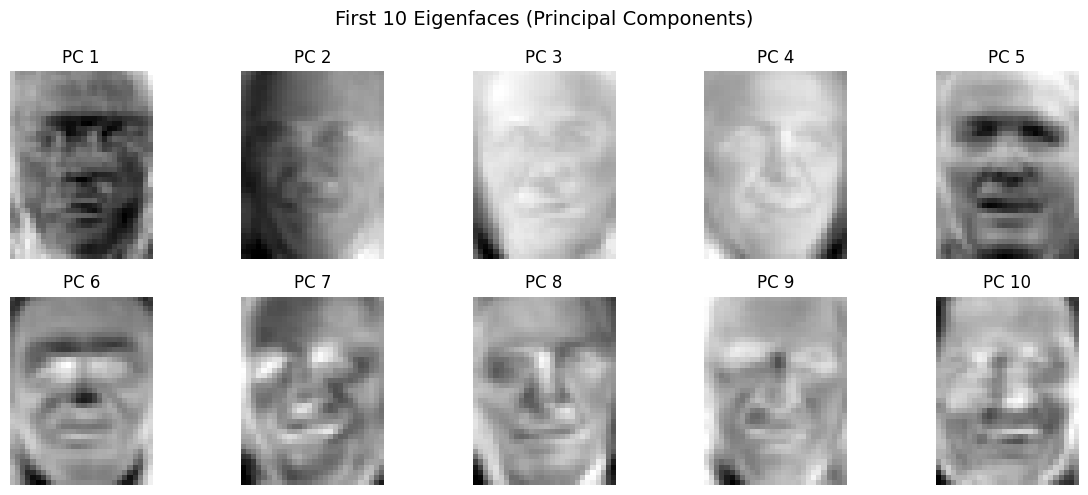

In [9]:
pca.plot_components((h, w))

Now, let's try to classify the data, using sklearn **SVC**.

In [10]:
x_train_pca = pca.transform(x_train)
x_test_pca = pca.transform(x_test)

classifier = SVC(kernel='rbf').fit(x_train_pca, y_train)

train_score = classifier.score(x_train_pca, y_train)
test_score = classifier.score(x_test_pca, y_test)

print(f"PCA + SVM Classifier Results:")
print(f"  Training accuracy: {train_score:.4f}")
print(f"  Test accuracy: {test_score:.4f}")

PCA + SVM Classifier Results:
  Training accuracy: 0.9876
  Test accuracy: 0.9130


### **2.3. Discussion of the results (0.5 pt):**
1. What is the concept of variance explainability and why is it so important?
1. What is the optimal number of components to reach good enough classification performance and why?

---
#### **Your answer here:**

**1. Variance Explainability**

Variance explainability (or explained variance ratio) measures how much of the total variability in the original data is captured by each principal component. When we perform PCA, we decompose the covariance matrix into eigenvalues and eigenvectors. The eigenvalues represent the amount of variance along each principal direction, and the ratio of each eigenvalue to the sum of all eigenvalues gives us the proportion of variance explained by that component.

This concept is crucial for several reasons. First, it provides a principled way to decide how many components to retain. If the first k components capture, say, 95% of the total variance, we can confidently discard the remaining components knowing we're only losing 5% of the information. Second, it helps us understand the intrinsic dimensionality of the data. Face images, despite having thousands of pixels, often lie on a much lower-dimensional manifold, and the variance explainability curve reveals this structure. Third, from a practical standpoint, reducing dimensionality while preserving most variance leads to faster training, reduced overfitting, and better generalization in downstream tasks like classification.

**2. Optimal Number of Components**

The optimal number of components depends on the specific task and involves a trade-off between information preservation and dimensionality reduction. For classification tasks, the goal isn't necessarily to preserve all variance but rather to retain the variance that's discriminative between classes.

In practice, 80-95% variance retention often works well as a starting point. Looking at the scree plot, we typically see an "elbow" where the curve bends, indicating that additional components contribute relatively little variance. For face recognition specifically, research has shown that using too few components misses important facial features, while using too many may include noise and irrelevant variations (like lighting artifacts), which can hurt classification.

The best approach is empirical: try different thresholds (say, 70%, 80%, 90%, 95%) and evaluate classification performance on a validation set. Interestingly, sometimes using fewer components than needed for high variance retention can improve classification because it acts as a form of regularization, filtering out noise that doesn't help distinguish between classes.

---

## 3. Fischerface classification and LDA (1.5 pt)
Now, having implemented the **PCA** algorithm, let's implement the **Linear Discriminant Analysis** algorithm.

By this [link](https://towardsdatascience.com/fishers-linear-discriminant-intuitively-explained-52a1ba79e1bb) you can read more about this algorithm.

In this task we will see how we can improve our classification using **LDA**.

### **3.1 Implementation (1 pt)**
Here you only need to compute the $\mathbf{\it{S_B}}$ and $\mathbf{\it{S_W}}$ covariance matrices, discussed in the source above, and select appropriate eigenvectors

In [11]:
class MYLDA:

    def fit(self, data, data_labels, k_components):
        n_feats = data.shape[-1]
        SW = np.zeros((n_feats, n_feats))
        SB = np.zeros((n_feats, n_feats))
        mu = data.mean(0)  # Overall mean

        # ========= YOUR CODE STARTS HERE ========= #

        for c in np.unique(data_labels):
            # get all samples belonging to class c
            X_c = data[data_labels == c]
            n_c = X_c.shape[0]  # Number of samples in class c

            # class mean
            mu_c = X_c.mean(0)

            # within-class scatter: sum of (x - mu_c)(x - mu_c)^T for all x in class c
            X_c_centered = X_c - mu_c
            SW += X_c_centered.T @ X_c_centered

            # between-class scatter: n_c * (mu_c - mu)(mu_c - mu)^T
            mean_diff = (mu_c - mu).reshape(-1, 1)
            SB += n_c * (mean_diff @ mean_diff.T)

        # ========== YOUR CODE ENDS HERE ========== #

        # solve generalized eigenvalue problem: SB @ v = lambda * SW @ v
        # add small regularization to SW to ensure it's invertible
        SW += np.eye(n_feats) * 1e-6

        evals, evecs = scipy.linalg.eigh(SB, SW)

        # sort eigenvectors by eigenvalues in descending order and select top k
        idx = np.argsort(evals)[::-1]
        evecs = evecs[:, idx]
        self.proj = evecs[:, :k_components]

    def transform(self, data):
        return data @ self.proj

Here we will implement the class for the Fischerface algorithm, which basically uses an **LDA** on top of **PCA**, such that we will perform maximum dimensionality reduction for classification purposes:

In [12]:
class FischerFaces:
    def __init__(self) -> None:
        """
        Initialize pca and lda
        """
        self.pca = MYPCA()
        self.lda = MYLDA()

    def fit(self, X, Y, threshold, lda_components):
        """
        Fit the fischerface algo:
        1. Fit PCA
        2. Reduce data dimensions with PCA
        3. Fit LDA
        """
        self.pca.fit(X, exp_threshold=threshold)

        pca_trans = self.pca.transform(X)

        self.lda.fit(pca_trans, Y, lda_components)

    def transform(self, X):
        """
        Transform the data by using fitted PCA and LDA
        """
        pca_transformed = self.pca.transform(X)
        return self.lda.transform(pca_transformed)

Now, let's try out our new classifier based on Fischerface algorithm.

*Hint*: select the number of LDA components equal to the number of classes

In [13]:
# for binary classification, we have 2 classes, so LDA can produce at most 1 component
# (number of classes - 1)
n_classes = len(np.unique(y_train))
lda_components = n_classes - 1  # for C classes, LDA produces at most C-1 components

f = FischerFaces()
f.fit(x_train, y_train, threshold=0.95, lda_components=lda_components)

x_train_fisher = f.transform(x_train)
x_test_fisher = f.transform(x_test)

classifier_fisher = SVC(kernel='rbf').fit(x_train_fisher, y_train)

train_score_fisher = classifier_fisher.score(x_train_fisher, y_train)
test_score_fisher = classifier_fisher.score(x_test_fisher, y_test)

print(f"Fischerfaces (PCA + LDA) + SVM Classifier Results:")
print(f"Training accuracy: {train_score_fisher:.4f}")
print(f"Test accuracy: {test_score_fisher:.4f}")
print(f"\nComparison with Eigenfaces (PCA only):")
print(f"PCA Test accuracy: {test_score:.4f}")
print(f"Fischerfaces Test accuracy: {test_score_fisher:.4f}")

Fischerfaces (PCA + LDA) + SVM Classifier Results:
Training accuracy: 0.9938
Test accuracy: 0.9420

Comparison with Eigenfaces (PCA only):
PCA Test accuracy: 0.9130
Fischerfaces Test accuracy: 0.9420


### **3.2 Discussion (0.5 pt)**
Evaluate the results of Fishcerface classifier (LDA). Discuss whether it performs better than the classic Eigenface algorithm (PCA), and if so, why

---
#### **Your explanations come here**

The Fischerface algorithm, which combines PCA with Linear Discriminant Analysis (LDA), is designed to address a fundamental limitation of the Eigenface approach. While both methods reduce dimensionality, they optimize for different objectives, and this distinction has important implications for classification performance.

PCA finds directions of maximum variance in the data, treating all samples equally regardless of their class labels. This is an unsupervised approach that captures the most significant sources of variation, which might include lighting conditions, facial expressions, or background variations. However, the directions of maximum variance aren't necessarily the most useful for distinguishing between different individuals. A dramatic lighting change, for instance, might create more variance than the subtle differences between two people's facial features.

LDA, in contrast, is a supervised method that explicitly incorporates class label information. It seeks directions that maximize the ratio of between-class scatter to within-class scatter. In other words, LDA looks for projections where samples from the same class cluster tightly together while samples from different classes are pushed apart. This is directly aligned with what we want for classification.

The Fischerface algorithm cleverly combines both approaches. It first uses PCA to reduce the data to a manageable dimensionality (avoiding the singularity issues that would arise from applying LDA directly to high-dimensional pixel data), and then applies LDA to find the most discriminative directions within this reduced space. This two-stage process typically yields superior classification results because the final projection is optimized for separating classes rather than just capturing variance.

In practice, Fischerfaces tends to be more robust to variations in lighting and facial expression because these variations affect all faces similarly (adding to within-class scatter) and are therefore suppressed by LDA's optimization criterion. The method essentially learns to focus on the features that differ between individuals while ignoring the features that vary within each person's set of images.

The theoretical maximum number of LDA components is C-1 for C classes, which for binary classification means just one component. Despite this seemingly severe dimensionality reduction, this single dimension is chosen to be maximally discriminative, often leading to excellent classification performance with a much simpler model.

---